In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/muhammadumer7804/online-retail-sales-ii/online_retail_II.xlsx


# **Step 1 — Project Title & Overview**

# 🛒 From Raw Data to Business Insights: Retail Sales Data Cleaning & Visualization

## 📌 Project Overview

This project demonstrates a complete data analysis workflow using a real-world retail sales dataset.

The objective is to transform raw transactional data into a clean, reliable dataset and uncover meaningful business insights through data cleaning, feature engineering, and visualization.

### 🎯 Project Objectives

- Load and merge retail sales data
- Assess data quality
- Clean missing, duplicate, and invalid records
- Perform feature engineering
- Explore sales trends using visualizations
- Generate business insights from the cleaned dataset

### 🛠️ Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### 📂 Dataset

**Online Retail Sales II**

# **Step 2 — Import Required Libraries**

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print(" Libraries imported successfully.")

 Libraries imported successfully.


# **Step 3 — Load the Excel File**

In [3]:
file_path = "/kaggle/input/datasets/muhammadumer7804/online-retail-sales-ii/online_retail_II.xlsx"

excel_file = pd.ExcelFile(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


# **Step 4 — Check the Worksheet Names**

In [4]:
sheet_names = excel_file.sheet_names

print("Available Worksheets:")

for sheet in sheet_names:
    print(f"- {sheet}")

Available Worksheets:
- Year 2009-2010
- Year 2010-2011


# **Load the Data from Both Worksheets**

In [5]:
df_2009 = pd.read_excel(file_path, sheet_name="Year 2009-2010")
df_2010 = pd.read_excel(file_path, sheet_name="Year 2010-2011")

print("2009-2010 Shape :", df_2009.shape)
print("2010-2011 Shape :", df_2010.shape)

2009-2010 Shape : (525461, 8)
2010-2011 Shape : (541910, 8)


# **Step 5 — Add a Year Column**

## 🏷️ Add Year Identifier

Before merging the datasets, we add a **Year** column to each DataFrame.

This preserves the source of every transaction after combining both worksheets.

In [6]:
df_2009["Year"] = "2009-2010"
df_2010["Year"] = "2010-2011"

print("Year column added successfully.")

Year column added successfully.


# **Step 6 — Merge Both DataFrames**

In [7]:
df = pd.concat([df_2009, df_2010], ignore_index=True)

print("Datasets merged successfully.")
print(f"Dataset Shape: {df.shape}")

Datasets merged successfully.
Dataset Shape: (1067371, 9)


# **Step 7 — First Look at the Dataset**

In [8]:
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 1,067,371
Columns : 9


# **Step 8 — Display the First 5 Rows**

In [9]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-2010


In [10]:
print(df.shape[0])
print(df.shape[1])

1067371
9


# **Step 9 — Preview Dataset**

In [11]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-2010


In [12]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-2010
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,2009-2010
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-2010
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom,2009-2010
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,2009-2010
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom,2009-2010


In [13]:

df.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year
633056,545460,85053,FRENCH ENAMEL CANDLEHOLDER,1,2011-03-02 17:33:00,2.10,13230.0,United Kingdom,2010-2011
610771,543467,22470,HEART OF WICKER LARGE,1,2011-02-08 14:35:00,5.79,NaN,United Kingdom,2010-2011
265559,515024,21153,RED SPOTTY TABLECLOTH,4,2010-07-08 10:06:00,10.65,12975.0,United Kingdom,2009-2010
503754,536464,21814,HEART T-LIGHT HOLDER,2,2010-12-01 12:23:00,1.45,17968.0,United Kingdom,2009-2010
163167,504916,21670,BLUE SPOT CERAMIC DRAWER KNOB,16,2010-04-19 10:28:00,2.51,NaN,United Kingdom,2009-2010


In [14]:
df.sample(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year
660826,547892,22726,ALARM CLOCK BAKELIKE GREEN,4,2011-03-28 10:15:00,3.75,12669.0,France,2010-2011
294683,518080,22077,6 RIBBONS RUSTIC CHARM,12,2010-08-04 13:57:00,1.65,15628.0,United Kingdom,2009-2010
606076,543044,47566,PARTY BUNTING,5,2011-02-03 08:18:00,4.65,17071.0,United Kingdom,2010-2011
847241,565201,22938,CUPCAKE LACE PAPER SET 6,12,2011-09-01 16:41:00,1.95,14907.0,United Kingdom,2010-2011
885510,568208,22945,CHRISTMAS METAL TAGS ASSORTED,12,2011-09-25 15:35:00,0.85,12783.0,Portugal,2010-2011
234438,512093,21731,RED TOADSTOOL LED NIGHT LIGHT,24,2010-06-13 13:06:00,1.65,16954.0,United Kingdom,2009-2010
574077,540469,22423,REGENCY CAKESTAND 3 TIER,3,2011-01-07 14:04:00,12.75,12484.0,Spain,2010-2011
262006,514670,22423,REGENCY CAKESTAND 3 TIER,4,2010-07-05 13:15:00,12.75,15611.0,United Kingdom,2009-2010
185405,507028,22456,NATURAL SLATE CHALKBOARD LARGE,6,2010-05-05 14:51:00,4.95,15704.0,United Kingdom,2009-2010
360691,524320,22306,SILVER MUG BONE CHINA TREE OF LIFE,6,2010-09-28 14:26:00,1.95,18049.0,United Kingdom,2009-2010


In [15]:
df.sample(5, random_state=42)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year
455941,532657,21314,SMALL GLASS HEART TRINKET POT,12,2010-11-14 11:10:00,2.10,14562.0,United Kingdom,2009-2010
826291,563214,22383,LUNCH BAG SUKI DESIGN,2,2011-08-14 12:56:00,1.65,16370.0,United Kingdom,2010-2011
191636,507597,22561,WOODEN SCHOOL COLOURING SET,12,2010-05-10 13:21:00,1.65,17700.0,United Kingdom,2009-2010
25864,491634,21588,RETRO SPOT GIANT TUBE MATCHES,1,2009-12-11 15:40:00,2.55,17841.0,United Kingdom,2009-2010
73233,496007,85232B,SET/3 RUSSIAN DOLL STACKING TINS,3,2010-01-28 12:32:00,4.95,15203.0,United Kingdom,2009-2010


# **Step 10 — Check the Dataset Structure**

In [16]:
print("=" * 60)
print("Dataset Information")
print("=" * 60)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
 8   Year         1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 73.3+ MB


# **Step 11 — Statistical Summary**

In [17]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice,1067371.0,53628.0,537434.0,1350.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1067371.0,NaN,NaN,NaN,9.938898,-80995.0,1.0,3.0,10.0,80995.0,172.705794
InvoiceDate,1067371,NaN,NaN,NaN,2011-01-02 21:13:55.394028544,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,1067371.0,NaN,NaN,NaN,4.649388,-53594.36,1.25,2.1,4.15,38970.0,123.553059
Customer ID,824364.0,NaN,NaN,NaN,15324.638504,12346.0,13975.0,15255.0,16797.0,18287.0,1697.46445
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,1067371,2,2010-2011,541910,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **Step 12 — Data Quality Assessment**

In [18]:
# Missing Values
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values("Missing Values", ascending=False)

print("Missing Values")
display(missing)

print(f"\nDuplicate Rows      : {df.duplicated().sum():,}")
print(f"Negative Quantity   : {(df['Quantity'] < 0).sum():,}")
print(f"Zero Quantity       : {(df['Quantity'] == 0).sum():,}")
print(f"Negative Price      : {(df['Price'] < 0).sum():,}")
print(f"Zero Price          : {(df['Price'] == 0).sum():,}")
print(f"Cancelled Orders    : {df['Invoice'].astype(str).str.startswith('C').sum():,}")

Missing Values


,Missing Values,Percentage
Customer ID,243007,22.77
Description,4382,0.41
Invoice,0,0.00
Quantity,0,0.00
StockCode,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00
Year,0,0.00



Duplicate Rows      : 12,133
Negative Quantity   : 22,950
Zero Quantity       : 0
Negative Price      : 5
Zero Price          : 6,202
Cancelled Orders    : 19,494


# **Step 13 — Data Cleaning**

In [19]:
print(f"Original Shape : {df.shape}")

# Remove duplicate rows
df = df.drop_duplicates()

# Remove cancelled orders
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# Remove invalid quantity
df = df[df["Quantity"] > 0]

# Remove invalid price
df = df[df["Price"] > 0]

# Remove missing descriptions
df = df.dropna(subset=["Description"])

print(f"Cleaned Shape  : {df.shape}")

Original Shape : (1067371, 9)
Cleaned Shape  : (1029609, 9)


# **Step 14 — Feature Engineering**

In [20]:
# Total Sales
df["Sales"] = df["Quantity"] * df["Price"]

# Month Name
df["Month"] = df["InvoiceDate"].dt.month_name()

# Day Name
df["Day"] = df["InvoiceDate"].dt.day_name()

# Purchase Hour
df["Hour"] = df["InvoiceDate"].dt.hour

print("Feature engineering completed successfully.")

Feature engineering completed successfully.


# **EDA (Exploratory Data Analysis)**

# **Step 15 — Monthly Sales Trend**

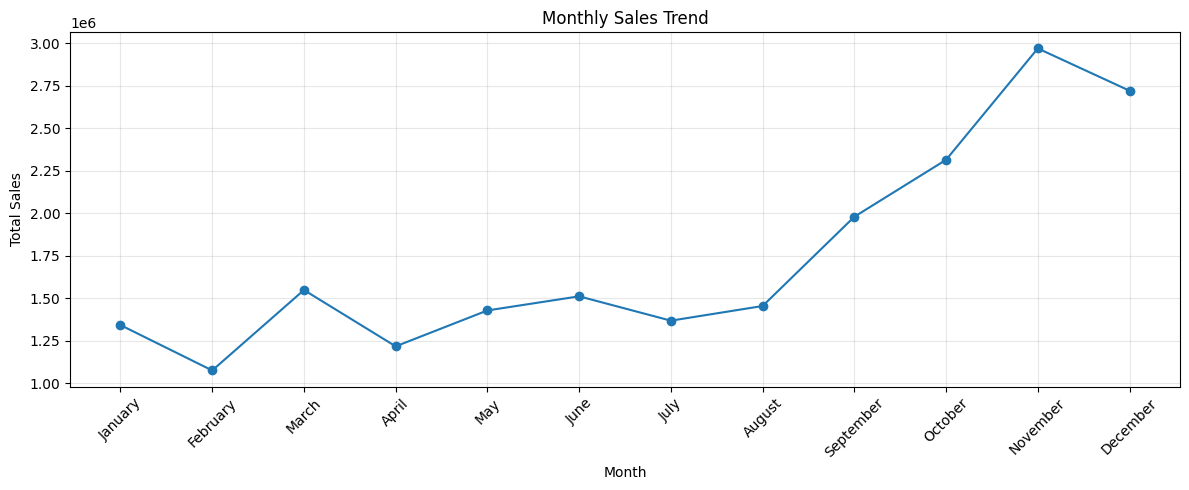

In [21]:

# Monthly Sales Trend


# Define month order
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
      .reindex(month_order)
)

plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# **Problem**
important issue

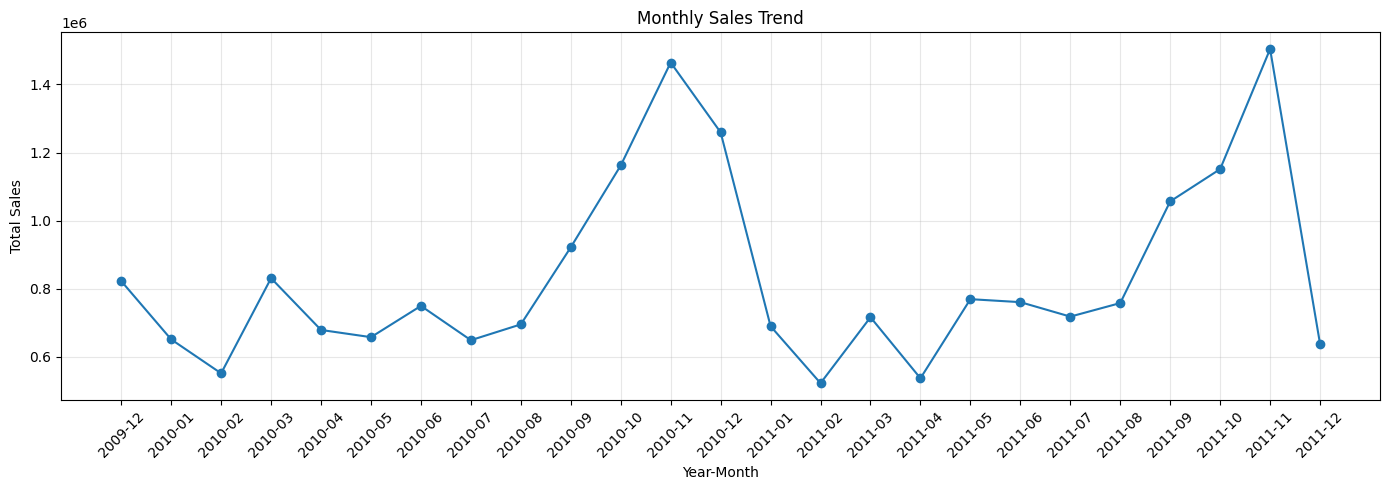

In [22]:
# Create Year-Month column
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

# Monthly Sales
monthly_sales = df.groupby("YearMonth")["Sales"].sum()

plt.figure(figsize=(14,5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# **Step 16 — Top 10 Best-Selling Products**

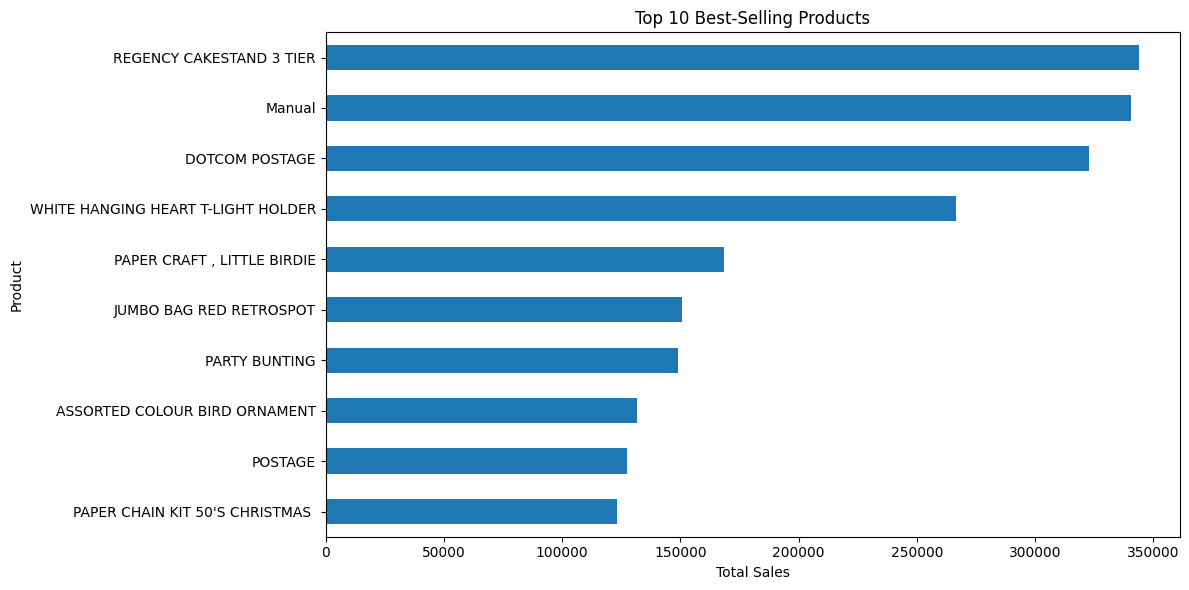

In [23]:

# Top 10 Best-Selling Products


top_products = (
    df.groupby("Description")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

# **Step 17 — Top 10 Countries by Sales**

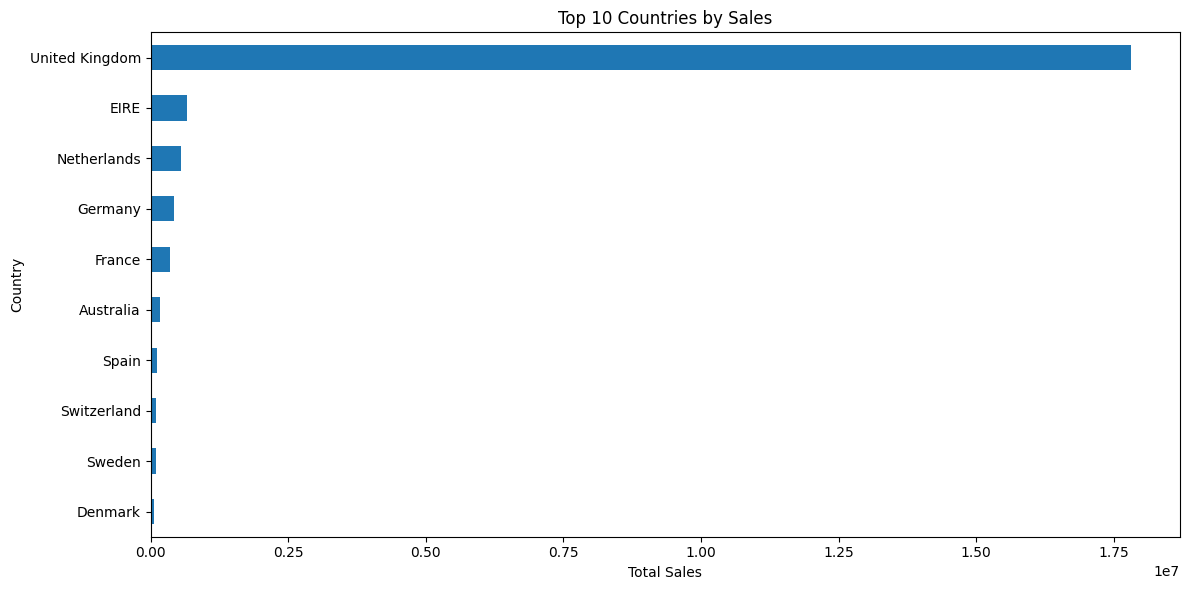

In [24]:

# Top 10 Countries by Sales


top_countries = (
    df.groupby("Country")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_countries.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")

plt.tight_layout()
plt.show()